In [77]:
SUBIR_A_KAGGLE = True
SEED = 42
RUTA_ARCHIVO_TEMPORAL_CUSTOM = True
TESTEO_RÁPIDO = True

</br>
<div style="display: flex; justify-content: space-between; align-items: flex-start; border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: -8px;">
    <div style="width: 50%;">
        <h2>
            <span style="color: #B30033;">▍</span>Práctica 2:
        </h2>
        <h1 style="margin-top: -10px;">
            Aprendizaje y selección de modelos de clasificación
        </h1>
    </div>
    <div style="width: 50%; text-align: right;">
        <div style="display: flex; justify-content: space-between; align-items: flex-start; margin-top: 30px;">
            <div style="width: 20%;"></div>
            <div style="width: 80%; border-left: 2px solid #555555; padding-left: 20px;">
                <div style="margin-bottom: 20px;">
                    <p style="margin: 0; font-size: 1.4em; font-weight: bold;">
                        Minería de Datos, 2025-26
                    </p>
                </div>
                <div style="margin-top: 8px; text-align: right;">
                    <span style="font-size: 1em; color: #D0D0D0;">
                        José Antonio Gámez Martín
                    </span>
                    <a href="mailto:Jose.Gamez@uclm.es" style="text-decoration: none; color: #888888; font-size: 0.8em; padding-left: 15px;">
                        ✉ Jose.Gamez@uclm.es
                    </a>
                </div>
                <div style="margin-top: 8px; text-align: right;">
                    <span style="font-size: 1em; color: #D0D0D0;">
                        Pablo Torrijos Arenas
                    </span>
                    <a href="mailto:Pablo.Torrijos@uclm.es" style="text-decoration: none; color: #888888; font-size: 0.8em; padding-left: 15px;">
                        ✉ Pablo.Torrijos@uclm.es
                    </a>
                </div>
                </div>
            </div>
        </div>
    </div>
</div>

<div style="border-bottom: 2px solid #555555; padding-bottom: 25px; margin-bottom: 10px">
    <div style="display: flex; align-items: center; margin-bottom: 10px;">
        <span style="color: #B30033; font-size: 1.5em; margin-right: 10px;">▍</span>
        <h3 style="margin: 0; font-size: 1.4em; font-weight: bold">
            Estudiantes
        </h3>
    </div>
    <ul style="list-style-type: none; padding-left: 28px; margin: 0;  font-size: 1.1em">
        <li>Alberto Pérez Álvarez</li>
        <li>Diego García Díaz</li>
    </ul>

</div>

## 1. Introducción

El objetivo de esta práctica es construir sobre el trabajo realizado en la Práctica 1. Se aplicarán y compararán diversos modelos de clasificación supervisada, utilizando validación cruzada y ajuste de hiperparámetros, para seleccionar el modelo más eficaz en la predicción del abandono estudiantil.

Para ello, continuaréis utilizando los mismos conjuntos de datos de la práctica anterior (`uclm_student_train.csv` y `uclm_student_test.csv`). El `Pipeline` de preprocesamiento desarrollado en la Práctica 1 servirá como base para el entrenamiento de los modelos (aunque podéis modificarlo).

Tendréis que explorar y evaluar los modelos de clasificación introducidos en el notebook complementario (`Material Práctica 2 - Modelos y Selección.ipynb`), junto con al menos un algoritmo adicional investigado de forma independiente, el cual tendréis que explicar más detalladamente. El rendimiento se evaluará rigurosamente mediante validación cruzada, y técnicas como `GridSearchCV` para encontrar la configuración óptima de hiperparámetros.

El modelo final seleccionado se utilizará para generar predicciones en el conjunto de prueba y participar en la competición de Kaggle.

### 1.1. Recordatorio: competición en Kaggle

La evaluación final se realizará mediante una competición privada en Kaggle. El objetivo es maximizar la métrica **F1-Score**, una medida robusta que tiene en cuenta tanto la precisión como la exhaustividad, especialmente útil en casos con clases desbalanceadas.

* **Enlace a la competición**: https://www.kaggle.com/t/16fef7f5d88c4dd399f8bad259c55947

Los equipos con mejor rendimiento en el *private leaderboard* recibirán una bonificación en la nota final:
* **1er puesto**: +0.75 puntos.
* **2º puesto**: +0.5 puntos.
* **3er puesto**: +0.25 puntos.

**Nota**: Las bonificaciones están sujetas a la revisión del código y la metodología. Se podrá requerir una justificación del enfoque para verificar la originalidad y la comprensión del trabajo.

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px"></div>

## 2. Carga de Datos y Preprocesamiento Base

Como punto de partida, cargaremos los datos igual que en la Práctica 1:

In [78]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df_train_raw = pd.read_csv('./csv/uclm_student_train.csv')
df_train_raw

,id,nombre,nacimiento,provincia,residencia_id,trabaja,horas_trabajo,bachillerato,nota_acceso,modalidad,creditos_a1,superados_a1,nota_s1,satisfaccion,horas_moodle,posts_foro,uso_biblioteca,eventos,tutorias,comentarios,numero_fav,talla_zapato,color_fav,meses_matriculado,grupo_trabajo,abandono
0,TO-2010-GCA531,Graciano Cano Alsina,1992-05-06,Albacete,E1-P02-H04,0,NaN,Científico,6.08,Tiempo completo,60,60,8.16,4.32,~7.2 horas,2,11,1,4,relacion correcto con compañeros,71,43,Azul oscuro,6,GR10335,1
1,CU-2016-MBP239,María Belén Polo,1998-10-31,Cuenca,E2-P03-H06,0,NaN,CIENCIAS PURAS,8.12,Tiempo completo,60,60,9.09,4.05,~11.8 horas,13,2,2,0,Uso normal de la plataforma Moodle,22,38,Coral claro,6,GR13813,0
2,CR-2010-JS201,Judith Sáenz,1992-03-11,Ciudad Real,NaN,0,NaN,Ciencias Puras,10.59,Tiempo completo,60,54,7.99,3.88,~8.8 horas,6,14,2,3,NaN,69,37,Violeta oscuro,6,GR02505,0
3,TO-2016-CDB602,Casandra de Bautista,1998-11-03,Toledo,E1-P04-H18,0,NaN,Humanidades,7.85,Tiempo completo,60,48,7.27,3.81,~8.7 horas,0,0,2,3,Relacion adecuado con compañeros.,3,34,Rosa profundo,6,GR14887,0
4,AB-2011-CAA364,Carlito Alvarado Anaya,1993-12-22,Albacete,NaN,0,NaN,ECONÓMICO,10.23,Tiempo completo,60,60,8.45,4.08,~9.6 horas,16,6,2,3,ha mejorado notablemente en asignaturas troncales,19,39,Coral claro,5,GR09244,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40540,AB-2011-CB913,Cecilia Bosch,1993-04-14,Albacete,NaN,0,NaN,CIENCIAS SOCIALES,8.64,Tiempo completo,60,36,5.52,2.94,~1.1h,8,0,3,0,NaN,23,39,Rojo violeta medio,6,GR15949,1
40541,TO-2011-WRL313,Wilfredo Roda Lerma,1987-11-12,Toledo,NaN,1,NaN,Económico,10.59,Tiempo completo,60,60,9.00,4.05,~11.5 horas,8,2,3,2,NaN,76,40,Amarillo,6,GR11547,0
40542,CR-2017-JA946,Javi Acuña,1999-09-05,Ciudad Real,NaN,0,NaN,TECNOLÓGICO,10.41,Tiempo completo,60,54,NaN,3.52,~5.1 horas,3,8,4,4,Expresa dudas sobre continuar los estudios.,24,40,Gris claro,4,GR00625,1
40543,AB-2010-TRM306,Teresita Rodrigo Morera,1992-06-23,Albacete,NaN,0,NaN,Económico,10.15,Tiempo completo,60,54,7.36,3.70,~8.0 horas,10,3,4,0,NaN,39,38,Azul real,6,GR06859,0


In [79]:
df_test_raw = pd.read_csv('csv/uclm_student_test.csv')
df_test_raw

,id,nombre,nacimiento,provincia,residencia_id,trabaja,horas_trabajo,bachillerato,nota_acceso,modalidad,creditos_a1,superados_a1,nota_s1,satisfaccion,horas_moodle,posts_foro,uso_biblioteca,eventos,tutorias,comentarios,numero_fav,talla_zapato,color_fav,meses_matriculado,grupo_trabajo
0,AB-2019-FEM764,Fabiola Espejo Marín,2002-01-12,Ciudad Real,E1-P01-H01,0,NaN,CCSS,10.17,Tiempo completo,60,48,7.74,3.81,~11.0 horas,16,14,5,5,Expresa dudas sobre su vocacion.,43,40,Violeta sonrojado pálido,6,GR01091
1,TO-2018-ALL744,Arsenio Lucas Llanos,2000-06-13,Toledo,NaN,0,NaN,Letras,9.16,Tiempo completo,60,48,6.99,3.28,~6.8 horas,2,5,5,1,NaN,88,40,Cian,6,GR02931
2,AB-2018-ZSD099,Zaira Salvà Dominguez,2000-09-25,Albacete,NaN,0,NaN,Ciencias Puras,8.91,Tiempo completo,60,60,8.28,4.48,10.0,12,2,6,2,Busca activamente prácticas y oportunidades pr...,96,39,Gris oscuro,3,GR06795
3,CR-2019-TCS733,Tatiana Celia Solano Tejera,2001-06-05,Ciudad Real,NaN,0,NaN,Letras,9.29,Tiempo completo,60,24,3.96,1.86,~0.8 horas,10,6,3,1,NaN,62,38,Blanco lavanda,6,GR06712
4,CR-2018-VBV597,Victoriano Benavente Vilaplana,2000-06-18,Ciudad Real,NaN,0,NaN,Letras,5.00,Tiempo completo,60,0,2.85,1.26,~5.9 horas,17,2,2,0,NaN,98,44,Azul Alicia,2,GR01653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9582,AB-2019-AAM365,Albino Acero Múgica,2002-02-14,Albacete,NaN,0,NaN,Tecnológico Industrial,9.38,Tiempo completo,60,30,4.74,2.20,~4.2 horas,11,1,5,0,NaN,98,41,Marrón siena,6,GR13835
9583,AB-2019-MC507,Marina Calleja,2002-01-07,Albacete,NaN,0,NaN,CCSS,6.41,Tiempo completo,60,60,9.52,4.97,~8.4 horas,3,7,6,2,Asistencia constante a clases.,33,38,Amarillo,6,GR14729
9584,AB-2019-MNC716,Morena Noelia Castell Amor,2001-04-05,Albacete,NaN,0,NaN,Letras,9.60,Tiempo completo,60,24,5.09,2.35,7.8,2,9,2,2,Habla de cambiar de ciudad por motivos persona...,96,35,Azul anciano,6,GR11046
9585,AB-2018-ICH450,Isidora Cabrera Hoyos,2001-02-09,Albacete,NaN,1,NaN,CCSS,9.79,Tiempo completo,60,48,7.05,3.59,11.5,12,1,2,2,NaN,82,37,Blanco,6,GR10480


Las variables disponibles son:
`id`, `nombre`, `nacimiento`, `provincia`, `residencia_id`, `trabaja`, `horas_trabajo`, `bachillerato`, `nota_acceso`, `modalidad`, `creditos_a1`, `superados_a1`, `nota_s1`, `satisfaccion`, `horas_moodle`, `posts_foro`, `uso_biblioteca`, `eventos`, `tutorias`, `comentarios`, `numero_fav`, `talla_zapato`, `color_fav`, `meses_matriculado`, `grupo_trabajo`, `abandono`.

La variable objetivo es `abandono`, que es binaria:
* **1**: El estudiante abandona los estudios.
* **0**: El estudiante continúa.

Se puede observar cómo hay variables categóricas, numéricas, fechas, texto, valores faltantes... Esto requerirá de un análisis exploratorio y un preprocesamiento.

<div style="border-bottom: 2px solid #555555; padding-bottom: 15px; margin-bottom: 10px">

Y a partir de aquí reutilizaremos el pipeline de preprocesamiento definido en la Práctica 1. Podéis modificarlo como creáis conveniente, ya que a la hora de trabajar con los modelos podéis seguir descubriendo información de las variables. 

Es fundamental encapsular todas las transformaciones (imputación, escalado, codificación, ingeniería de características) desarrolladas previamente en un único `Pipeline` o `ColumnTransformer` para aplicarlo consistentemente antes de cada modelo.

*Recordatorio: Asegúrate de que tu pipeline de preprocesamiento maneja adecuadamente todos los tipos de variables y artefactos presentes en los datos (`numéricas`, `categóricas`, `fechas`, `texto`, `valores faltantes`, etc.)*.

## Importaciones adicionales

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import unicodedata
import category_encoders as ce
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import KNNImputer
from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import KBinsDiscretizer

from sklearn.base import BaseEstimator, TransformerMixin # Para el imputer personalizado
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import cross_validate
import warnings

import tempfile
import shutil
from joblib import parallel_backend
import gc
import platform
from sklearn.decomposition import PCA

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.base import ClassifierMixin, check_is_fitted

# P2
import sys
import time
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import GridSearchCV
import time
import joblib

#from optbinning import MDLP
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import CategoricalNB 
# Imports de Scikit-Learn (Ensemble)
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
# Import modelo adicional
from sklearn.svm import SVC

# Imports de librerías externas que requieren instalación: pip install xgboost lightgbm
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from category_encoders import OrdinalEncoder

from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Identificadores de SO
Para ejecutar con distintas preferencias según el ordenador. Una manera rápida de distinguir quién de los dos ejecuta la libreta.

In [81]:
class list_os:
    linux = "Linux"
    macos = "Darwin"

## Análisis de los datos

### Tipos de clases
Para cada pipeline tenemos una división de características almacenada en una lista.

Además de las típicas divisiones entre continuas/numéricas, también tenemos distintas configuraciones para el árbol de decisión y para naive bayes. Además también tratamos distintamente variables en las que la propia falta de información es información (mnar) y las que vamos a discretizar. 

En adición, en "useless" están las variables descartadas por ser inútiles, y tenemos definidas más listas para pasarles a los distintos transformadores en los pipeline.

In [82]:
'''DECISION TREE (DT)'''
# Variables discretas (valores enteros contables, como categorías codificadas o conteos)
categorical_cols_DT = [
    "trabaja",
    "uso_biblioteca",
    "creditos_a1",
    "superados_a1",
    "eventos",
    "tutorias",
    "meses_matriculado",
    "bachillerato",
    "modalidad",
    "comentarios",
    "residencia_id", # Da mejor DT, algo peor NB
    "grupo_trabajo", # A naive bayes le empeora, a DT le aumenta
]

categorical_mode_cols_DT = [
    "provincia",
    "numero_fav",
    "talla_zapato", # Aumenta la puntuación, (y como categórica más)
]

# Variables continuas (valores numéricos con posibles decimales)
numerical_cols_DT = [
    "nota_acceso",
]

numerical_mnar_cols_DT = [
    "horas_moodle",  # Necesita pasarse de string a float
    "horas_trabajo",    # Muchos NaN, si son todos NaN habría que quitarla
    "satisfaccion",
    "nota_s1",
]

numerical_discretize_cols_DT = [
    # Peor rendimiento con satisfaccion y nota_s1 (las no gaussianas/normales)
]

'''NAIVE BAYES (NB)'''
categorical_cols_NB = [
    "trabaja",
    "eventos",
    "tutorias",
    "meses_matriculado",
    "bachillerato",
    "modalidad",
    "comentarios",
    "residencia_id",
]

categorical_mode_cols_NB = [
    "provincia",
    "numero_fav",
    "talla_zapato", # Aumenta la puntuación, (y como categórica más)
]

numerical_cols_NB = [
    "nota_acceso",  
]

numerical_mnar_cols_NB = [
    "horas_moodle",  # Necesita pasarse de string a float
    "horas_trabajo",    # Muchos NaN
    "superados_a1",
    "creditos_a1",
        "nota_s1",      
]

numerical_discretize_cols_NB = [
    "satisfaccion",
    "uso_biblioteca",
]

# Variables de texto libre (respuestas abiertas, tipo string)
string_cols = [
    "id",
]

# Variables de fechas
date_cols = [
    "nacimiento"
]

mnar_custom_cols = [ # Se pueden repetir en otras listas
    'nota_s1'
]

useless = [
    "posts_foro", # baja la puntuación
    "nombre",
    "color_fav",    # Como categorica da menos
]

## Feature Engineering

### Tratamiento variables especiales
Aquí tratamos las variables que requieren algun procesado especial, en concreto la fecha ( pasarla a float ), y el grupo de trabajo ( extraer el número como un entero ).

In [83]:
df_train = df_train_raw.copy()
df_train["horas_moodle"] = df_train["horas_moodle"].str.extract(r'([\d.]+)').astype(float)

df_test = df_test_raw.copy()
df_test["horas_moodle"] = df_test["horas_moodle"].str.extract(r'([\d.]+)').astype(float)

df_train["grupo_trabajo"] = df_train["grupo_trabajo"].str[2:].astype(int).values.reshape(-1, 1)
df_test["grupo_trabajo"] = df_test["grupo_trabajo"].str[2:].astype(int).values.reshape(-1, 1)

### Tratamiento intensivo de comentarios (Fuga de datos)
Esta función predice directamente el abandono en caso de detectar un comentario con una tasa de abandono tanto del 100% o 0%. Actualmente esta tasa se calcula con un csv generado previamente para el análisis de los comentarios, pero esto es una fuga de datos. Para evitar una fuga de datos es necesario calcular los datos del csv dinamicamente con la partición de KFold. Aunque no nos haya dado tiempo a implementarlo bien, lo dejamos pues creemos que es interesante.

In [84]:
def comentarios():
    nombre_archivo = './temp/resumen_comentarios_abandono_con_tasa.csv' 
    minimo_comentarios = 0

    df = pd.read_csv(nombre_archivo)

    df['tasa_abandono'] = pd.to_numeric(df['tasa_abandono'], errors='coerce')

    cond_tasa_0 = df['tasa_abandono'] == 0.0
    cond_tasa_100 = df['tasa_abandono'] == 100.0
    cond_minimo = df['total_comentarios'] >= minimo_comentarios

    tasa_0 = set(df[cond_tasa_0 & cond_minimo]['comentarios'])
    tasa_100 = set(df[cond_tasa_100 & cond_minimo]['comentarios'])

    return (tasa_0,tasa_100)

(comentario_no_abandona,comentario_si_abandona) = comentarios()

class ModeloConReglas(BaseEstimator, ClassifierMixin):
    """
    Un estimador que aplica reglas de abandono o no para los comentarios antes de usar el modelo, saltandose su prediccion.
    """
    
    def __init__(self, pipeline_base, set_si_abandona, set_no_abandona, columna_comentario='comentarios'):
        self.pipeline_base = pipeline_base
        self.set_si_abandona = set_si_abandona
        self.set_no_abandona = set_no_abandona
        self.columna_comentario = columna_comentario

    def separar_indices(self, X):
        """Helper para encontrar qué filas van a las reglas y cuáles al modelo."""
        # Convertir X a DataFrame si es un array
        if not isinstance(X, pd.DataFrame):
            raise ValueError("X debe ser un DataFrame de pandas para aplicar reglas")

        # Indices para la regla "SI abandona" (predecir 1)
        id_si_abandona = X[X[self.columna_comentario].isin(self.set_si_abandona)].index
        
        # Índices para la regla "NO abandona" (predecir 0)
        id_no_abandona = X[X[self.columna_comentario].isin(self.set_no_abandona)].index

        # Indices de las filas que NO están en ninguna regla
        id_reglas = id_si_abandona.union(id_no_abandona)
        id_modelo_base = X.index.difference(id_reglas)
        
        return id_si_abandona, id_no_abandona, id_modelo_base

    def fit(self, X, y):
        """
        Entrena el modelo base SÓLO en los datos
        que no están cubiertos por las reglas.
        """
        # Asegurarnos de que 'y' sea una Serie de pandas para indexar
        if not isinstance(y, pd.Series):
            y_series = pd.Series(y, index=X.index)
        else:
            y_series = y
            
        # Guardamos las clases
        self.classes_ = np.unique(y)
        
        # Separamos los datos
        _, _, id_modelo_base = self.separar_indices(X)
        
        # Creamos los datos de entrenamiento para el modelo base
        X_fallback = X.loc[id_modelo_base]
        y_fallback = y_series.loc[id_modelo_base]

        # Entrenamos el pipeline base SÓLO con esos datos
        self.pipeline_base = self.pipeline_base.fit(X_fallback, y_fallback)
            
        self.is_fitted = True
        return self

    def predict(self, X):
        """
        Predice usando las reglas primero, y luego el modelo base.
        """
        check_is_fitted(self, 'is_fitted_')

        idx_si_abandona, idx_no_abandona, idx_modelo_base = self.separar_indices(X)
        
        # creamos un array de predicciones (empezamos con NaNs)
        predicciones = pd.Series(np.nan, index=X.index)

        # Aplicamos regla SI abandona (predice 1)
        predicciones.loc[idx_si_abandona] = 1
        
        # Aplicamos regla NO abandona (predice 0)
        predicciones.loc[idx_no_abandona] = 0
        
        # usamos el modelo base para el resto
        if not idx_modelo_base.empty:
            X_fallback = X.loc[idx_modelo_base]
            pred_fallback = self.pipeline_base.predict(X_fallback)
            predicciones.loc[idx_modelo_base] = pred_fallback
        predicciones = predicciones.fillna(-1).astype(int) 

        return predicciones.values

    def predict_proba(self, X):
        """
        Devuelve probabilidades. 100% para las reglas,
        y las del modelo base para el resto.
        """
        check_is_fitted(self, 'is_fitted_')
        
        idx_si_abandona, idx_no_abandona, idx_modelo_base = self.separar_indices(X)
        
        # array de probabilidades [prob_0, prob_1]
        probas = pd.DataFrame(np.nan, index=X.index, columns=[0, 1])
        
        # Regla SI (Prob 1 = 100%)
        probas.loc[idx_si_abandona, 0] = 0.0
        probas.loc[idx_si_abandona, 1] = 1.0
        
        # Regla NO (Prob 0 = 100%)
        probas.loc[idx_no_abandona, 0] = 1.0
        probas.loc[idx_no_abandona, 1] = 0.0
        
        if not idx_modelo_base.empty:
            X_fallback = X.loc[idx_modelo_base]
            # Si el modelo base puede hacer predict_proba
            if hasattr(self.pipeline_base, "predict_proba"):
                probas_fallback = self.pipeline_base.predict_proba(X_fallback)
                probas.loc[idx_modelo_base, 0] = probas_fallback[:, 0]
                probas.loc[idx_modelo_base, 1] = probas_fallback[:, 1]
            else:
                # Si no hay predict_proba, usamos predict y asignamos un 100%
                pred_fallback = self.pipeline_base.predict(X_fallback)
                probas.loc[idx_modelo_base, 0] = 1.0 - pred_fallback # (si pred=1 -> prob_0=0)
                probas.loc[idx_modelo_base, 1] = pred_fallback       # (si pred=1 -> prob_1=1)

        return probas.fillna(0.5).values # Rellenar por si acaso

### Discretizar numéricas
Algunas variables no siguen una distribución normal, lo que afecta gravemente al score de Naive Bayes. Para solucionarlo, las discretizamos.
Probamos a usar la discretización supervisada por entropía, pero al no estar implementada en sklearn importamos la clase MDLP de un paquete externo.
También intentamos implementar una aproximación usando un modelo de árbol de decisión. 

Por último probamos con la discretización por cuartiles, que terminó siendo la que mejor resultado proporcionó. 

In [85]:
class MDLPDiscretizer(BaseEstimator, TransformerMixin):
    """
    implementación de MDLP (Fayyad-Irani)
    """
    def __init__(self, **mdlp_params):
        self.mdlp_params = mdlp_params
        self.discretizers = {} 
        self.features = None

    def fit(self, X, y):
        X_df = pd.DataFrame(X) 
        self.features = X_df.columns.tolist()

        if y is None:
            raise ValueError("MDLP Discretizer requires target variable 'y'.")

        y_array = np.array(y) 

        for col in self.features:
            discretizer = MDLP(**self.mdlp_params)
            discretizer.fit(X_df[col].values, y_array)
            
            self.discretizers[col] = discretizer
        
        return self

    def transform(self, X):
        X_df = pd.DataFrame(X)
        X_discretized = np.zeros(X_df.shape, dtype=np.int32)
        
        for i, col in enumerate(self.features):
            mdlp_object = self.discretizers[col]
            
            splits = mdlp_object.splits
            
            X_discretized[:, i] = np.digitize(X_df[col].values, splits)

        return X_discretized
    
class DecisionTreeDiscretizer(BaseEstimator, TransformerMixin):
    """
    Simula la discretización supervisada por entropía (como MDLP) 
    utilizando un Árbol de Decisión.
    """
    def __init__(self, n_bins=3, max_depth=None):
        # max_leaf_nodes limita el número de bins (N Bins = max_leaf_nodes)
        self.n_bins = n_bins
        self.max_depth = max_depth
        self.discretizers = {} # Almacena los modelos de árboles (uno por feature)

    def fit(self, X, y=None):
        X = pd.DataFrame(X)
        y = pd.Series(y)
        
        if y is None:
            raise ValueError("Supervised discretizer requires target variable 'y'.")

        for col in X.columns:
            # Entrenamos un árbol de decisión SOLO con la feature actual
            dt = DecisionTreeClassifier(
                max_leaf_nodes=self.n_bins,
                max_depth=self.max_depth,
                random_state=SEED
            )
            dt.fit(X[[col]], y)
            self.discretizers[col] = dt

        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        X_discretized = pd.DataFrame()

        for col in X.columns:
            dt = self.discretizers[col]
            
            # Aplicamos el modelo entrenado para obtener el ID de la hoja que actúa como el bin 
            leaf_ids = dt.apply(X[[col]])
            
            # Convertimos los IDs de las hojas en un formato de entero para los bins
            X_discretized[col] = pd.Series(leaf_ids, index=X.index)

        return X_discretized.values # Devuelve un array de NumPy compatible con sklearn
    
entropy_discretizer =  MDLPDiscretizer() # se queda igual

entropy_discretizer_dtd = DecisionTreeDiscretizer(n_bins=2) # Peor rendimiento

quantile_discretizer = KBinsDiscretizer(n_bins=4, encode='onehot', strategy='quantile', quantile_method='linear')

### Tratamiento de variables correlacionadas
Combinamos las variables correlacionadas en una sola columna con PCA. Probamos también a usar la media y eliminar una de las dos, pero ambos métodos daban peor resultado que simplemente no tratarlas.

In [86]:
pca_DT = PCA(n_components=0.95)
pca_NB = PCA(n_components=0.95)

### Tratamiento de fechas
Intentamos tratar las fechas para comprobar si mejoraban el rendimiento de algún modelo, pero no fué el caso.

In [87]:
class DateFeatureTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        pass

    def fit(self, X, y=None):
        self.output_features_ = ['year', 'month_sin', 'month_cos'] + [f'day_{i}' for i in range(1, 32)]
        return self

    def transform(self, X):     
        date_series = pd.to_datetime(X.iloc[:, 0], errors='coerce')

        X_transformed = pd.DataFrame()
        
        # Creamos la categorías
        X_transformed['year'] = date_series.dt.year
        month_values = date_series.dt.month
        X_transformed['month_sin'] = np.sin(2 * np.pi * month_values / 12) # De esta manera el modelo tiene en cuenta que el mes 12 es seguido del 1
        X_transformed['month_cos'] = np.cos(2 * np.pi * month_values / 12)

        # One-hot para los dias del mes
        day_values = date_series.dt.day
        X_transformed['day'] = day_values
        day_dummies = pd.get_dummies(day_values, prefix='day', dummy_na=False)
        
        # Comprobamos que todos los dias estan presentes, y si no los añadimos
        for day in range(1, 32): 
            col_name = f'day_{day}'
            if col_name not in day_dummies.columns:
                day_dummies[col_name] = 0
        
        # Reordenamos según el día
        day_dummies = day_dummies[[f'day_{day}' for day in range(1, 32)]]
        
        X_transformed = pd.concat([X_transformed, day_dummies], axis=1)

        return X_transformed 

### Reemplazado de Outliers
Calculamos unos límites en función de los cuartiles y un factor personalizable. Seguidamente reemplazamos los valores extremos por esos límites.

In [88]:
class OutlierCapperIQR(BaseEstimator, TransformerMixin):
    """
    Aplica un límite a los outliers de una columna numérica
    """
    
    def __init__(self, factor=1.5):
        self.factor = factor
        self.upper_limits = {}
        self.lower_limits = {}

    def fit(self, X, y=None):
        """
        Calcula los límites superior e inferior para cada columna
        """
            
        for col in X.columns:
            # Calculamos Q1, Q3 y rango intercuartílico
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            
            self.lower_limits[col] = Q1 - (self.factor * IQR)
            self.upper_limits[col] = Q3 + (self.factor * IQR)
            
        return self

    def transform(self, X):
        X_transformed = X.copy()
        
        for col in X.columns:
            lower_limit = self.lower_limits[col]
            upper_limit = self.upper_limits[col]
            
            # Reemplazamos valores extremos por los límites.
            X_transformed[col] = np.clip(
                X_transformed[col], 
                lower_limit, 
                upper_limit
            )
            
        return X_transformed

### Limpieza de variables categóricas
Algunas variables categóricas cuentan indistintamente con mayúsculas y minúsculas, tildes, espacios...

In [89]:
FILL_VALUE = 'Desconocido'

class TextCleanerImputer(BaseEstimator, TransformerMixin):
    def __init__(self, fill_value=FILL_VALUE):
        self.fill_value = fill_value

    def fit(self, X, y=None):
        # Si fill_value es 'mode', calculamos y guardamos las modas
        if self.fill_value == "mode":
            # .mode() devuelve un DataFrame, .iloc[0] toma la primera moda
            # .to_dict() lo convierte en {columna: moda}
            self.modes_ = X.mode().iloc[0].to_dict()
        return self

    def _remove_accents(self, text):
        if pd.isna(text):
            return text
        return ''.join(
            c for c in unicodedata.normalize('NFKD', str(text))
            if not unicodedata.combining(c)
        )

    def transform(self, X):
        X_transformed = X.copy()
        for col in X_transformed.columns:

            # Determinamos el valor de relleno
            if self.fill_value == "mode":
                # Usamos la moda guardada para esa columna.
                # .get(col, "") usa "" si la columna no se vio en fit
                fill_val = self.modes_.get(col, "")
            else:
                fill_val = self.fill_value

            X_transformed[col] = (
                X_transformed[col]
                .fillna(fill_val)
                .astype(str)
                .str.lower()
                .apply(self._remove_accents)
                .str.strip()
                .str.replace(r'[\"\.,]', '', regex=True)
                .str.replace(r'\s+', ' ', regex=True)
            )
        return X_transformed

#### Limpieza de ceros y NaN
Unifica los valores '0' y "Desconocido" generado por el imputer, uniendolos en uno único.

In [90]:
class UnificarCeroDesconocido(BaseEstimator, TransformerMixin):
    """
    Toma una columna y unifica los valores 'Desconocido' y 0 en una sola categoría (0).
    """
    
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Creamos una copia para evitar el SettingWithCopyWarning
        col_transformada = X.iloc[:, 0].copy()

        # Reemplazamos 'Desconocido' por 0
        col_transformada = col_transformada.replace('Desconocido', 0)
        
        # Convertimos toda la columna a numérico. Con coarce vovlemos nan 
        col_numerica = pd.to_numeric(col_transformada, errors='coerce')
        
        col_rellenada = col_numerica.fillna(0) 

        # Devolvemos el array 2D de NumPy que el pipeline espera
        return col_rellenada.values.reshape(-1, 1)

### Creación de columnas custom
Hemos investigado la creación de varias columnas adicionales, aunque muy pocas han resultado mejorar el rendimiento.

In [91]:
class CreateMissingIndicator(BaseEstimator, TransformerMixin):
    """
    Crea una columna binaria que indica si el valor
    en la columna de entrada es nulo (NaN).
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return X.isnull().astype(int).values.reshape(-1, 1)
    
class CreateZeroIndicator(BaseEstimator, TransformerMixin):
    """
    Crea una columna binaria que indica si el valor
    en la columna de entrada es 0.
    """
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        return (X == 0).astype(int).values
    
class SameResidencyAndWorkGroupIndicator(BaseEstimator, TransformerMixin):
    """
    Crea una columna binaria si pertenecen a:
        - Misma residencia
        - Mismo grupo de trabajo
    """
    def fit(self, X, y = None):
        return self
    
    def transform(self, X):
        """
        Calcula la nueva característica binaria.
        """
        residencia = X['residencia_id'].astype(str)
        grupo_trabajo = X['grupo_trabajo'].astype(str)

        indicator = (residencia == grupo_trabajo).astype(int)

        return indicator.values.reshape(-1, 1)
    
class GroupMeanEncoder(BaseEstimator, TransformerMixin):
    """
    Calcula la media de nota_s1 de un grupo a partir de sus integrantes
    """
    def __init__(self, group_col, target_col, new_col_name):
        self.group_col = group_col
        self.target_col = target_col
        self.new_col_name = new_col_name
        self.group_means_ = {}
        self.imput_value = 0

    def fit(self, X, y=None):
        # Calculamos la media
        self.group_means_ = X.groupby(self.group_col)[self.target_col].mean()
        return self
    def transform(self, X):
        X_transformed = X.copy()
        
        X_transformed[self.new_col_name] = X_transformed[self.group_col].map(self.group_means_)
        
        # Rellenamos valores NAN con 0
        X_transformed[self.new_col_name].fillna(self.imput_value, inplace=True)
        
        return X_transformed

### Limpieza de variables numéricas
Dependiendo del grupo de variables el funcionamiento de cada imputador es distinto. Para las numéricas un KNN con 7 vecinos ha sido el que mejor resultados ha conseguido. Para las mnar usamos un SimpleImputer con el flag de indicador de NaNs activado. 

Además, para nota_s1 (presente tanto en el grupo mnar del árbol de decisión como para naive bayes) es mucho más óptimo rellenar con ceros, pues alumnos que no hayan hecho el examen tendrán uno.

In [92]:
imputer_numerical = KNNImputer(n_neighbors=7)
imputer_iterative = IterativeImputer(max_iter=10, random_state=SEED)

imputer_mnar_DT = SimpleImputer(strategy='constant', add_indicator=True, fill_value=0)
imputer_mnar_NB = SimpleImputer(strategy='constant', add_indicator=True, fill_value=0)

### Codificadores
Hemos probado los codificadores onehot, ordinal y target. Este último ha sido el que mejor resultados nos ha dado. Además, encontramos que para el árbol de decisión
es mejor un smoothing de 10 y para naive bayes de 20.

In [93]:
target_encoder_DT = ce.TargetEncoder(smoothing=10.0)
target_encoder_NB = ce.TargetEncoder(smoothing=20.0)

onehot_encoder_DT = ce.OneHotEncoder() 
onehot_encoder_NB = ce.OneHotEncoder() # Funciona mucho peor y necesita MUCHA memoria (poner n_jobs = 1 o activar downsampling).

ordinal_encoder_DT = ce.OrdinalEncoder() # Aún peor que onehot.
ordinal_encoder_NB = ce.OrdinalEncoder() # Aún peor que onehot.

## Pipelines

### Inicialización
Hemos implementado un amplio número de pipelines para adaptarnos a las características de cada grupo de variables. Hemos implementado pipelines específicas tanto para el arbol de decisión (DT) como naive bayes (NB). 

In [94]:
# Pipeline para Categóricas (Limpieza y luego Encoding) 
text_pipeline = Pipeline([
    ('limpiador_texto', TextCleanerImputer(fill_value=FILL_VALUE)),
])

text_pipeline_mode = Pipeline([
    ('limpiador_texto', TextCleanerImputer(fill_value="mode")),
])

# Pipelines para Numéricas (Imputación KNN)
numerical_pipeline_robustScaler = Pipeline([
    ('outlier_capper', OutlierCapperIQR(factor=1.5)),
    ('imputador_knn', imputer_numerical),
    ('scaler', RobustScaler(quantile_range=(25.0, 75.0))) # Peor rendimiento
])

numerical_pipeline_DT = Pipeline([
    ('outlier_capper', OutlierCapperIQR(factor=1.5)), # Ligeramente peor para NB, mejor para DT. Al revés en Kaggle, mejor NB y peor DT
    ('imputador_knn', imputer_numerical),
    ('scaler', StandardScaler()),
])

numerical_pipeline_mnar_DT = Pipeline([
    ('outlier_capper', OutlierCapperIQR(factor=1.5)), # No tiene efecto en la mnar
    ('imputador_mnar', imputer_mnar_DT),
    ('scaler', StandardScaler())
])

numerical_pipeline_discretize_DT = Pipeline([
    ('outlier_capper', OutlierCapperIQR(factor=1.5)),
    ('imputador_mnar', imputer_mnar_DT),
    ('discretizer', quantile_discretizer),
])

numerical_pipeline_NB = Pipeline([
    ('outlier_capper', OutlierCapperIQR(factor=1.5)), # Ligeramente peor para NB, mejor para DT. Al revés en Kaggle, mejor NB y peor DT
    ('imputador_knn', imputer_iterative),
    ('scaler', StandardScaler()),
])

numerical_pipeline_mnar_NB = Pipeline([
    ('outlier_capper', OutlierCapperIQR(factor=1.5)), # No tiene efecto en la mnar
    ('imputador_mnar', imputer_mnar_NB),
    ('scaler', StandardScaler())
])

numerical_pipeline_discretize_NB = Pipeline([
    ('outlier_capper', OutlierCapperIQR(factor=1.5)),
    ('imputador_mnar', imputer_mnar_NB),
    ('discretizer', quantile_discretizer),
])

catagorical_pipeline_catNB = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='_MISSING_')),
    ('encoder', OrdinalEncoder())
])

numerical_pipeline_catNB = Pipeline(steps=[
    ('outlier_capper', OutlierCapperIQR(factor=1.5)),
    ('imputer', SimpleImputer(strategy='median')),
    ('discretizer', KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='quantile')) 
])

date_pipeline = Pipeline([
    ('date_creator', DateFeatureTransformer()), 
    ('imputador_knn', imputer_numerical),
    ('scaler', StandardScaler())
])

missing_indicator_pipeline = Pipeline([
    ('missing_indicator', CreateMissingIndicator()), 
])

residency_work_pipeline = Pipeline([
    ('same_residency_group', SameResidencyAndWorkGroupIndicator()) 
])

zero_indicator_pipeline = Pipeline([
    ('zero_indicator', CreateZeroIndicator()) 
])

unify_0_NaN_pipeline = Pipeline(steps=[
    ('unificar_cero', UnificarCeroDesconocido()),
    ('escalador_horas', StandardScaler()) 
])

group_mean_pipeline = Pipeline(steps=[
    ('group_mean_encoder', GroupMeanEncoder(group_col='grupo_trabajo', 
        target_col='nota_s1', 
        new_col_name='avg_nota_grupo')),
    ('outlier_capper', OutlierCapperIQR(factor=1.5)),
    ('scaler', StandardScaler()),
])

### Preprocesador (Aplicar imputación, limpieza y columnas custom)
Contamos con dos preprocesadores, uno que se aplica mejor al modelo de árbol de decisión, y otro para naive bayes.
Algunas columnas creadas por nosotros terminaron bajando el rendimiento, por lo que están comentadas.

In [95]:
preprocessor_DT = ColumnTransformer(
    transformers=[
        # Aplicamos la limpieza de texto a las categóricas
        ('categorical', text_pipeline, categorical_cols_DT), 

        ('categorical_mode', text_pipeline_mode, categorical_mode_cols_DT),
        
        # Aplicamos la combinación de 0 y Desconocido en una sola
        ('combinar_0_y_desc', unify_0_NaN_pipeline, ["superados_a1","trabaja"]),

        # Añade una columna con la media de nota_s1 para el grupo de trabajo al que pertenece. Empeora el rendimiento.
        #'''('group_mean_encoder', group_mean_pipeline, ["grupo_trabajo","nota_s1"]),'''

        # Aplicamos la imputación a numéricas
        ('numerical', numerical_pipeline_DT, numerical_cols_DT),

        # Aplicamos la imputación a las numéricas que queremos mantener la falta de información
        ('num_mnar', numerical_pipeline_mnar_DT, numerical_mnar_cols_DT),

        # Aplicamos preprocesamiento a las fechas. Empeora el rendimiento en Kaggle y no lo mejora en train
        #'''('date', date_pipeline, date_cols)'''  

        # Añadimos una columna adicional para indicar NaNs. Esto es algo redundante pues también lo hace SimpleEncoder, 
        # pero encontramos que para nota_s1 mejora el rendimiento al añadirla
        ('missing_ind', missing_indicator_pipeline, mnar_custom_cols), 

        # Crea una columna que cuenta el numero de personas que comparten residencia y grupo de trabajo.
        #'''('res_work_ind', residency_work_pipeline, res_work_cols),'''
        
        # Aplicamos la discretización de variables continuas que no siguen una distribución normal.
        ('num_discretize', numerical_pipeline_discretize_DT, numerical_discretize_cols_DT),

        # Similar a missing_ind pero con ceros en vez de NaNs. Empeora el rendimiento
        #'''('zero_indicator', zero_indicator_pipeline, ["superados_a1"]),'''
    ],

    remainder='drop', # drop para que solo deje las columnas especificadas (numerical y categorical _cols) y quite el resto
                             # passthrough para que mantenga todas

    verbose_feature_names_out=False # Para que no prefije nombres de transformadores a las features
)

preprocessor_NB = ColumnTransformer(
    transformers=[
        # Aplicamos la limpieza de texto a las categóricas
        ('categorical', text_pipeline, categorical_cols_NB), 
        
        ('categorical_mode', text_pipeline_mode, categorical_mode_cols_NB),

        # Aplicamos la imputación a numéricas
        ('numerical', numerical_pipeline_NB, numerical_cols_NB),
        # Aplicamos la imputación a las numéricas que queremos mantener la falta de información
        ('num_mnar', numerical_pipeline_mnar_NB, numerical_mnar_cols_NB),

        ('num_discretize', numerical_pipeline_discretize_NB, numerical_discretize_cols_NB),

        # A Naive Bayes no le sienta bien el procesamiento de fechas, marcar los NANs en nota_s1, combinar los 0 y NaNs ni agregar la media 
        # de nota_s1 por grupo 
    ],

    remainder='drop', # drop para que solo deje las columnas especificadas (numerical y categorical _cols) y quite el resto
                             # passthrough para que mantenga todas

    verbose_feature_names_out=False # Para que no prefije nombres de transformadores a las features
)

preprocessor_CNB = ColumnTransformer(
    transformers=[
        ('num', numerical_pipeline_catNB, numerical_cols_NB+numerical_mnar_cols_NB+numerical_discretize_cols_NB),
        ('cat', catagorical_pipeline_catNB, categorical_cols_NB),
        #('num_discretize', numerical_pipeline_discretize_NB, numerical_discretize_cols_NB),
    ],
    remainder='drop'
)

## Entrenamiento de los modelos

### Separación y dropeo de variables
Eliminamos las variables que no hemos encontrado útiles, como las fechas o los posts del foro.

In [96]:
columns_to_drop = string_cols + useless

# Separamos el dataset de las variables a quitar
X_train = df_train.drop(columns=['abandono']).drop(columns=columns_to_drop)
y_train = df_train['abandono']

X_test = df_test.drop(columns=columns_to_drop)

# Verificar columnas faltantes entre train y test
missing_cols = set(X_train.columns) - set(X_test.columns)
if missing_cols:
    print(f"Columnas ausentes en test: {missing_cols}")

### Árbol de decisión

In [97]:
arbol_decision = DecisionTreeClassifier(random_state=SEED)

pipeline_DT = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_DT), 
    
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_DT), 

    # Para manejar variables correlacionadas
    ('pca', pca_DT),

    # Modelo de Clasificación/Regresión
    ('modelo', arbol_decision) 
])

'''
pipeline_DT = modelo_final_con_reglas = ModeloConReglas(
    pipeline_base=temp_pipeline,        
    set_si_abandona=comentario_si_abandona,
    set_no_abandona=comentario_no_abandona,
    columna_comentario='comentarios'     
)'''

#pipeline_DT.fit(X_train, y_train)

"\npipeline_DT = modelo_final_con_reglas = ModeloConReglas(\n    pipeline_base=temp_pipeline,        \n    set_si_abandona=comentario_si_abandona,\n    set_no_abandona=comentario_no_abandona,\n    columna_comentario='comentarios'     \n)"

### Naive Bayes

In [98]:
naive_bayes = GaussianNB()

pipeline_NB = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_NB), 
    
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_NB), 

    # Para manejar variables correlacionadas
    ('pca', pca_NB),
    
    # Modelo de Clasificación/Regresión
    ('modelo', naive_bayes) 
])

'''
pipeline_NB = modelo_final_con_reglas = ModeloConReglas(
    pipeline_base=temp_pipeline,        
    set_si_abandona=comentario_si_abandona,
    set_no_abandona=comentario_no_abandona,
    columna_comentario='comentarios'     
)'''

#pipeline_NB.fit(X_train,y_train)

"\npipeline_NB = modelo_final_con_reglas = ModeloConReglas(\n    pipeline_base=temp_pipeline,        \n    set_si_abandona=comentario_si_abandona,\n    set_no_abandona=comentario_no_abandona,\n    columna_comentario='comentarios'     \n)"

### Random Forest Classifier

In [99]:
random_forest_classif = RandomForestClassifier()

pipeline_RFC = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_DT), 
    
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_DT), 

    # Para manejar variables correlacionadas
    ('pca', pca_DT),

    # Modelo de Clasificación/Regresión
    ('modelo', random_forest_classif) 
])

### KNeighbors

In [100]:
knn_clasif = KNeighborsClassifier()

pipeline_KNN = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_NB), 
    
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_NB), 

    # Para manejar variables correlacionadas
    ('pca', pca_NB),
    
    # Modelo de Clasificación/Regresión
    ('modelo', knn_clasif) 
])

### Categorical Naive Bayes

In [101]:
categorical_naive_bayes = CategoricalNB()

pipeline_CNB =  Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_CNB),    
    
    # Modelo de Clasificación/Regresión
    ('modelo', categorical_naive_bayes) 
]) 

### Bagging Classifier

In [102]:
bagging_classif = BaggingClassifier(random_state=42, n_jobs=-1)

pipeline_BAG = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_DT), 
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_DT), 
    # Para manejar variables correlacionadas
    ('pca', pca_DT),
    # Modelo
    ('modelo', bagging_classif) 
])

### AdaBoost

In [103]:
adaboost_classif = AdaBoostClassifier(random_state=SEED)

pipeline_ADA = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_DT), 
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_DT), 
    # Para manejar variables correlacionadas
    ('pca', pca_DT),
    # Modelo
    ('modelo', adaboost_classif) 
])

### Gradient Boosting

In [104]:
gradient_boosting_classif = GradientBoostingClassifier(random_state=SEED)

pipeline_GB = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_DT), 
    
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_DT), 

    # Para manejar variables correlacionadas
    ('pca', pca_DT),

    # Modelo
    ('modelo', gradient_boosting_classif) 
])

### HistGradient Boosting

In [105]:
hist_gradient_boosting_classif = HistGradientBoostingClassifier(random_state=SEED)

pipeline_HGB = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_DT), 

    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_DT), 
    # Para manejar variables correlacionadas
    ('pca', pca_DT),
    # Modelo
    ('modelo', hist_gradient_boosting_classif) 
])

### XGBoost

In [106]:
xgb_classif = XGBClassifier(random_state=SEED, n_jobs=-1, eval_metric='logloss')

pipeline_XGB = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_DT), 
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_DT), 
    # Para manejar variables correlacionadas
    ('pca', pca_DT),
    # Modelo
    ('modelo', xgb_classif) 
])

### LightGBM

In [107]:
lgbm_classif = LGBMClassifier(random_state=SEED, n_jobs=-1, verbosity=-1)

pipeline_LGBM = Pipeline([
    # Imputación, Limpieza de Texto (No usa 'y')
    ('preprocessor', preprocessor_DT), 
    # Target Encoding (SÍ usa 'y' de entrenamiento del fold)
    ('encoder', target_encoder_DT),
    # Para manejar variables correlacionadas
    ('pca', pca_DT),
    # Modelo
    ('modelo', lgbm_classif) 
])

### Support Vector Classifier (SVC)
Este modelo clasifica trazando la frontera de mayor margen entre grupos, basandose en los puntos mas cercanos. Cuando los datos no se pueden dividir con una recta, se proeyctan los datos en una dimension superior, donde si se pueda dividir los datos. Se crean tantas dimensiones como sean necesarias para poder divir los datos.

In [108]:
svc_classifier = SVC(probability=True, random_state=SEED)

pipeline_SVC = Pipeline([
    ('preprocessor', preprocessor_DT), 
    ('target_encoder', target_encoder_DT), 
    ('pca_reduction', pca_DT),
    ('svc_classifier', svc_classifier) 
])

##  Validación cruzada

### Downcasting de variables para que ocupen menos en memoria
Reducir todas las variables posibles de 64 bits a 32 o 16 bits para reducir drásticamente el uso de memoria.
Penaliza mucho en kaggle pero para la F1 en train no altera prácticamente el resultado.

Originalmente lo necesitábamos para poder ejecutar la validación cruzada con todos los núcleos del procesador, pero una vez empezamos a tratar las 
numéricas mnar y a usar target encoder en vez de one hot se redujo drásticamente el uso de la RAM y dejó de ser necesario.

In [109]:
if platform.system() == list_os.macos:
    threads = 4
else:
    threads = -1
    
def do_downcasting():
    threads = -1

    cols_to_reduce = X_train.select_dtypes(include=np.number).columns

    for col in cols_to_reduce:
        # Downcast de floats (float64 a float32)
        if X_train[col].dtype == np.float64:
            X_train[col] = X_train[col].astype(np.float32)
        # Downcast de integers (int64 a int32 o int16)
        elif X_train[col].dtype == np.int64:
            # Comprobamos el rango
            X_train[col] = pd.to_numeric(X_train[col], downcast='integer')

    # Columnas a optimizar (categorical/string)
    categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns

    for col in categorical_cols:
        # Convertir objetos string a dtype para más eficiencia
        X_train[col] = X_train[col].astype('category')

    for col in categorical_cols:
        current_categories = list(X_train[col].cat.categories)
        
        if FILL_VALUE not in current_categories:
            new_categories = current_categories + [FILL_VALUE]
            
            # Poner las catagorías en el DataFrame
            X_train[col] = X_train[col].cat.set_categories(new_categories)

    return threads

''' YA NO ES NECESARIO 
if (not SUBIR_A_KAGGLE):
    threads = do_downcasting()
    (o si)'''

if (TESTEO_RÁPIDO):
    threads = do_downcasting()

### Ignorar entradas nulas con NaNs
Una entrada es nula si contiene muchos NaN. Probamos a ignorar las entradas con más de cierto número de valores perdidos, pero empeoraba el rendimiento.

In [110]:
# En este caso baja el score
def ignoreBadRows():
    umbral_valores_perdidos = 5
    mascara_filas_buenas = df_train_raw.isnull().sum(axis=1) < umbral_valores_perdidos
    sample_weights = mascara_filas_buenas.astype(int).values

### Logger para almacenar la salida de los modelos

In [111]:
class Logger:
    """
    Una clase que duplica la salida de sys.stdout a un fichero de log
    y a la consola original.
    """
    def __init__(self, filename, mode='w', encoding='utf-8'):
        self.original_stdout = sys.stdout
        # Asegura que la codificación UTF-8 se aplique
        self.logfile = open(filename, mode, encoding=encoding)
        print(f"--- Iniciando log en el fichero: {filename} ---")

    def write(self, message):
        """Escribe el mensaje en la consola original y en el fichero."""
        self.original_stdout.write(message)
        self.logfile.write(message)

    def flush(self):
        """
        Implementa el método flush, necesario para la interfaz de sys.stdout.
        Asegura que los búferes de ambos flujos se vacíen.
        """
        self.original_stdout.flush()
        self.logfile.flush()

    def close(self):
        """Cierra el fichero de log."""
        self.logfile.close()
        # Imprime un mensaje final en la consola original
        print(f"--- Log finalizado. Salida guardada en el fichero. ---", file=self.original_stdout)

### Optimización con Grid Search y obtención de resultados

In [ ]:
# Función sacada de la libreta de material
import os


def optimize_with_grid_search(estimator, param_grid, X_train, y_train, cv_strategy, scoring_metric='accuracy', refit=True, threads=-1, model_name = None):
    """
    Configura el Logger, ejecuta GridSearchCV y llama a la función de logging.
    Imprime los resultados en la consola Y en un fichero de log.
    """
    
    # nombre del modelo para el log
    if (model_name == None):
        model_name = type(estimator).__name__
        if isinstance(estimator, Pipeline):
            # Obtenemos el nombre del último paso (clasificador) si es un pipeline
            model_name = type(estimator.steps[-1][1]).__name__
    
    log_filename = f"./grid_search_output/{model_name}_grid_search_output.txt"
    log_directory = f"./grid_search_output"
    
    # ASEGURAR CARPETA GRIDSEARCH CREADA
    os.makedirs(log_directory, exist_ok=True)
    
    # Configuramos el Logger y redirigir stdout
    original_stdout = sys.stdout
    sys.stdout = Logger(log_filename)
    
    best_estimator = None # Variable para guardar el resultado

    try:
        n_jobs = threads
        return_train_score = True

        grid_search = GridSearchCV(
            estimator=estimator,
            param_grid=param_grid,
            scoring=scoring_metric,
            n_jobs=n_jobs,
            cv=cv_strategy,
            refit=refit,
            return_train_score=return_train_score,
            verbose=1
        )

        print(f"--- Iniciando GridSearchCV para {model_name} ---")
        start_time = time.time()
        grid_search.fit(X_train, y_train)
        end_time = time.time()
        fit_duration = end_time - start_time

        # Determinamos la métrica de 'refit' para pasarla a la función de log 
        if isinstance(refit, str):
            refit_metric_key = refit
        elif isinstance(scoring_metric, dict):
             # Si refit=True (no un string), y scoring es un dict, 
             # refit usa la *primera* métrica por defecto.
             refit_metric_key = next(iter(scoring_metric))
        else:
             # Si scoring es un string simple
             refit_metric_key = scoring_metric

        log_grid_search_results(grid_search, model_name, fit_duration, refit_metric_key)

        print(f"\n--- Fin de la optimización para {model_name} ---")

    finally:
        # Restaurar la salida estándar
        if isinstance(sys.stdout, Logger):
            logger_instance = sys.stdout
            sys.stdout = original_stdout # Restaurar
            logger_instance.close() 

    return grid_search.best_estimator_

def log_grid_search_results(grid_search, model_name, fit_duration, refit_metric_key):
    """
    Toma los resultados del GridSearchCV ya ajustado y los imprime/loggea.
    """
    
    print(f"GridSearchCV para {model_name} completado en {fit_duration:.2f} segundos.")

    # --- Procesar y Mostrar Resultados ---
    print(f"\nMejores Parámetros encontrados para {model_name}:")
    print(str(grid_search.best_params_)) # Usar str() para asegurar formato texto
    
    print(f"\nMejor Puntuación Media CV ({refit_metric_key}): {grid_search.best_score_:.4f}")

    results_df = pd.DataFrame(grid_search.cv_results_)
    rank_col_name = f"rank_test_{refit_metric_key}"

    if rank_col_name in results_df.columns:
        results_df = results_df.sort_values(by=rank_col_name)

    param_cols = [col for col in results_df.columns if col.startswith('param_')]
    score_cols = [col for col in results_df.columns if ('mean_test_' in col or 'std_test_' in col or col.startswith('rank_test_'))]
    train_score_cols = [col for col in results_df.columns if ('mean_train_' in col or 'std_train_' in col)]
    time_cols = ['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time']

    cols_to_display = param_cols + [col for col in score_cols if col in results_df.columns] + \
                      [col for col in train_score_cols if col in results_df.columns] + \
                      [col for col in time_cols if col in results_df.columns]
    cols_to_display = sorted(list(set(cols_to_display)), key=lambda x: (not x.startswith('param_'), x))

    print(f"\n--- Resumen de Resultados GridSearchCV para {model_name} ---")
    
    # Solo en el fichero
    file_content = (
        "\n"
        f"{results_df[cols_to_display].to_string()}\n"
        "\n--- FIN: Resumen de resultados ---\n"
    )
    sys.stdout.logfile.write(file_content)

    # Resultados formateados en la tabla (solo para la libreta)
    display(results_df[cols_to_display])

### Funciones para ejecutar la validación cruzada

In [113]:
# Archivo temporal para usar como caché

if platform.system() == list_os.linux and RUTA_ARCHIVO_TEMPORAL_CUSTOM:
    SSD_TEMP_DIR = "/mnt/ntfs/kosos/alber/Linux/PYTHON/temp"
else:
    SSD_TEMP_DIR = tempfile.mkdtemp()

#cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=5,
    random_state=SEED
)

scoring_metrics = ['accuracy', 'f1'] #'f1_macro'

def run_cross_validation(model_pipeline, param_grid, model_name = None):
    return optimize_with_grid_search(
        estimator=model_pipeline,
        param_grid=param_grid,
        X_train=X_train,
        y_train=y_train,
        cv_strategy=cv,
        scoring_metric=scoring_metrics,
        refit='f1', # Refit usando la métrica 
        model_name = model_name
    )

'''    return cross_validate(
        estimator=model_pipeline, 
        X=X_train, 
        y=y_train, 
        cv=cv, 
        scoring=scoring_metrics,  
        n_jobs=threads # -1 = Todos los cores
    )'''

def get_stats(cv_results):
    mean_accuracy = cv_results['test_accuracy'].mean()
    std_accuracy = cv_results['test_accuracy'].std()
    mean_f1 = cv_results['test_f1'].mean()
    std_f1 = cv_results['test_f1'].std()

    return (mean_accuracy, std_accuracy, mean_f1, std_f1)

def print_results(mean_accuracy, std_accuracy, mean_f1, std_f1):
    print(f"Cross-validation accuracy: {mean_accuracy:.4f} ± {std_accuracy:.4f}")
    print(f"Cross-validation F1-score: {mean_f1:.4f} ± {std_f1:.4f}")

def cross_validation(model_pipeline, param_grid, model_name = None):
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=FutureWarning)  # Filtrar los avisos de "futuro"

            # Backend de paralelismo bloqueando los procesos paralelos (n_jobs) a usar exclusivamente un hilo (Ahorro de memoria, menos duplicación)
            with parallel_backend('loky', temp_folder=SSD_TEMP_DIR,inner_max_num_threads=1):
                cv_results = run_cross_validation(model_pipeline, param_grid, model_name)
            
        #(mean_accuracy, std_accuracy, mean_f1, std_f1) = get_stats(cv_results)

        #print_results(mean_accuracy, std_accuracy, mean_f1, std_f1)

        #model_pipeline.fit(X_train, y_train) # Para sacar el predict posteriormente
    
    finally:
        # Eliminar los archivos temporales de caché
        shutil.rmtree(SSD_TEMP_DIR, ignore_errors=True)
        return cv_results

def cross_validation_batch(models_dic):
    for model in models_dic:
        if (model.do_train):
            gc.collect()
            model.result = cross_validation(model.pipeline,model.param_grid,model.name)
            joblib.dump(model.result, f'./saved_models/{model.name}.joblib')
            model.in_memory = True
    return models_dic

### Árbol de decisión

In [114]:
gc.collect()


if(TESTEO_RÁPIDO):
    param_grid_DT = {
        # Se prueba un solo criterio para agilizar.
        'modelo__criterion': ['entropy']
    }
else:
    # Grilla de búsqueda completa para 'DecisionTreeClassifier'.
    param_grid_DT = {
        # Criterios a evaluar (Gini y Entropía).
        'modelo__criterion': ['gini', 'entropy'],
        # Profundidad máxima del árbol.
        'modelo__max_depth': [None, 10, 20, 30, 50],
        # Mínimo de muestras para dividir un nodo.
        'modelo__min_samples_split': [2, 5, 10],
        # Mínimo de muestras en nodo hoja.
        'modelo__min_samples_leaf': [1, 2, 4],
        # Parámetro de complejidad para la poda del árbol.
        'modelo__ccp_alpha': [0.0, 0.001, 0.01, 0.1]
    }

#results_DT = cross_validation(pipeline_DT,param_grid_DT)

### Naive Bayes

In [115]:
gc.collect()

if (TESTEO_RÁPIDO):
    param_grid_NB = {
        'modelo__var_smoothing': np.logspace(-9, 0, num=1) # 30 valores entre 1e-9 y 1e0
    }
else:
    param_grid_NB = {
        'modelo__var_smoothing': np.logspace(-9, 0, num=30) # 30 valores entre 1e-9 y 1e0
    }

#results_NB = cross_validation(pipeline_NB, param_grid_NB)

### Random Forest Classiefier

In [116]:
if (TESTEO_RÁPIDO):
    param_grid_RFC = {
        'modelo__n_estimators': [50],
        'modelo__max_features': ['sqrt'],
        'modelo__max_depth': [None]
    }
else:
    param_grid_RFC = {
        # Número de árboles
        'modelo__n_estimators': [100, 200, 500],
        # Criterio de división
        'modelo__criterion': ['gini', 'entropy'],
        # Máximo de características por división
        'modelo__max_features': ['sqrt', 0.5, 0.7], 
        # Profundidad máxima del árbol
        'modelo__max_depth': [10, 20, 30, None],
        # Mínimo de muestras para dividir un nodo
        'modelo__min_samples_split': [2, 5, 10],
        # Mínimo de muestras en nodo hoja
        'modelo__min_samples_leaf': [1, 2, 4]
    }

### KNeighbours Classifier

In [117]:
if (TESTEO_RÁPIDO):
    # Grilla Rápida
    param_grid_KNN = {
        # Evalúa pocos vecinos (K)
        'modelo__n_neighbors': [5],
    }
else:
    # Grilla Completa
    param_grid_KNN = {
        # Rango de vecinos (K)
        'modelo__n_neighbors': [3, 5, 7, 9, 11, 15],
        # Tipo de peso ('uniforme' o por 'distancia')
        'modelo__weights': ['uniform', 'distance'],
        # Métrica de distancia
        'modelo__metric': ['euclidean', 'manhattan', 'minkowski'],
        # Orden 'p' para métrica Minkowski (p=1 Manhattan, p=2 Euclidiana)
        'modelo__p': [1, 2],
    }

### Categorical Naive Bayes

In [118]:
if (TESTEO_RÁPIDO):
    param_grid_CNB = {
        # Prueba el valor por defecto
        'modelo__alpha': [1.0],
    }
else:
    param_grid_CNB = {
        # Parámetro de suavizado (Laplace/Lidstone smoothing)
        # Valores entre 0 y 1 son comunes. 0.0 es sin suavizado.
        'modelo__alpha': [0.0, 0.5, 1.0, 2.0, 5.0],
        
        # Si se usa un alpha=0.0 (sin suavizado), este previene log(0)
        'modelo__fit_prior': [True, False], 
    }

### Bagging Classifier

In [119]:
if (TESTEO_RÁPIDO):
    param_grid_BAG = {
        'modelo__n_estimators': [50],
    }
else:
    param_grid_BAG = {
        # Número de estimadores base
        'modelo__n_estimators': [50, 100, 200],
        # Fracción de muestras para entrenar cada estimador
        'modelo__max_samples': [0.5, 0.8, 1.0],
        # Fracción de características para entrenar cada estimador
        'modelo__max_features': [0.5, 0.8, 1.0],
    }

### Ada Boost

In [120]:
if (TESTEO_RÁPIDO):
    param_grid_ADA = {
        'modelo__n_estimators': [50],
    }
else:
    param_grid_ADA = {
        # Número de estimadores
        'modelo__n_estimators': [50, 100, 200, 300],
        # Tasa de aprendizaje (controla la contribución de cada estimador)
        'modelo__learning_rate': [0.01, 0.1, 0.5, 1.0],
    }

### Gradient Boosting

In [121]:
if (TESTEO_RÁPIDO):
    param_grid_GB = {
        'modelo__n_estimators': [100],
        'modelo__learning_rate': [0.1],
    }
else:
    param_grid_GB = {
        'modelo__n_estimators': [100, 200, 300],
        'modelo__learning_rate': [0.01, 0.1, 0.2],
        # Profundidad de los árboles
        'modelo__max_depth': [3, 5, 8],
        # Fracción de muestras usadas para el ajuste (Stochastic GB)
        'modelo__subsample': [0.7, 0.9, 1.0],
    }

### HistGradientBoosting

In [122]:
if (TESTEO_RÁPIDO):
    param_grid_HGB = {
        'modelo__max_iter': [100],
    }
else:
    param_grid_HGB = {
        # Número de iteraciones (similar a n_estimators)
        'modelo__max_iter': [100, 200, 300],
        'modelo__learning_rate': [0.01, 0.1, 0.2],
        # Máximo de nodos hoja
        'modelo__max_leaf_nodes': [31, 50, 100],
        # Regularización L2
        'modelo__l2_regularization': [0.0, 0.1, 1.0],
    }

### XGBoost

In [123]:
if (TESTEO_RÁPIDO):
    param_grid_XGB = {
        'modelo__n_estimators': [100],
        'modelo__max_depth': [3],
    }
else:
    param_grid_XGB = {
        'modelo__n_estimators': [100, 200, 500],
        'modelo__learning_rate': [0.01, 0.1],
        'modelo__max_depth': [3, 5, 7],
        # Fracción de muestras
        'modelo__subsample': [0.7, 0.9],
        # Fracción de características por árbol
        'modelo__colsample_bytree': [0.7, 0.9],
        # Regularización L1 (alpha) y L2 (lambda)
        'modelo__reg_alpha': [0, 0.1, 0.5],
        'modelo__reg_lambda': [1, 0.1, 0.5],
    }

### Light GBM

In [124]:
if (TESTEO_RÁPIDO):
    param_grid_LGBM = {
        'modelo__n_estimators': [50],
        'modelo__num_leaves': [31],
    }
else:
    param_grid_LGBM = {
        'modelo__n_estimators': [100, 200, 500],
        'modelo__learning_rate': [0.01, 0.1],
        # Número de hojas (parámetro clave en LGBM)
        'modelo__num_leaves': [31, 50, 100],
        # Fracción de características
        'modelo__feature_fraction': [0.7, 0.9],
        # Fracción de datos (bagging)
        'modelo__bagging_fraction': [0.7, 0.9],
        'modelo__bagging_freq': [1], # Frecuencia de bagging
    }

### SVC

In [ ]:
if (TESTEO_RÁPIDO):
    param_grid_SVC = {
        'svc_classifier__C': [1.0],
        'svc_classifier__kernel': ['rbf'],
    }
else:
    param_grid_SVC = {
        # Parámetros del Pipeline 
        # Suavizado del encoder (controla el ruido de las categorías).
        'target_encoder__smoothing': [10.0], 
        # Componentes del PCA. SVM sufre mucho con muchas dimensiones inútiles.
        'pca_reduction__n_components': [0.95, 0.99],

        # Parámetros del Modelo 
        # Parámetro de regularización 'C'. 
        # Valor bajo = frontera más suave (más error permitido). Valor alto = frontera ajustada (menos error, riesgo de overfitting).
        'svc_classifier__C': [0.1, 1.0, 10.0],
        
        # Tipo de Kernel (la fórmula matemática para proyectar los datos).
        # 'rbf' (Radial Basis Function) es el estándar para datos no lineales. 'poly' es polinómico.
        'svc_classifier__kernel': ['rbf', 'poly'],
        
        # Coeficiente del kernel (para rbf/poly). 
        # 'scale' usa 1 / (n_features * X.var()), suele funcionar mejor que 'auto'.
        'svc_classifier__gamma': ['scale', 'auto'],
    }

### Modelos en conjunto

In [ ]:
class model:
    def __init__(self, name, pipeline, param_grid, result = None, prediction = None, do_train = False, do_predict = False):
        self.name = name
        self.pipeline = pipeline
        self.param_grid = param_grid
        self.result = result
        self.prediction = prediction
        self.in_memory = False
        self.do_train = do_train
        self.do_predict = do_predict

models_dic = [
    #model('DT',pipeline_DT, param_grid_DT),
    #model('NB',pipeline_NB, param_grid_NB),
    #model('RFC',pipeline_RFC, param_grid_RFC),
    #model('KNN', pipeline_KNN, param_grid_KNN),
    #model('CNB', pipeline_CNB, param_grid_CNB, do_train=False, do_predict=True),
    #model('BAG', pipeline_BAG, param_grid_BAG),
    #model('ADA', pipeline_ADA, param_grid_ADA),
    #model('GB', pipeline_GB, param_grid_GB),
    #model('HGB', pipeline_HGB, param_grid_HGB),
    #model('XGB', pipeline_XGB, param_grid_XGB),
    #model('LGBM', pipeline_LGBM, param_grid_LGBM),
    model('SVC', pipeline_SVC, param_grid_SVC, do_train=True)
]

if (TESTEO_RÁPIDO):
    for model in models_dic:
        model.name = model.name + "_test"

models_dic = cross_validation_batch(models_dic)

--- Iniciando log en el fichero: ./grid_search_output/SVC_test_grid_search_output.txt ---
--- Iniciando GridSearchCV para SVC_test ---
Fitting 25 folds for each of 1 candidates, totalling 25 fits


/Users/diego/dev/Analisis-de-Datos-y-Modelos-de-Prediccion-de-Abandono-Academico/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV para SVC_test completado en 605.25 segundos.

Mejores Parámetros encontrados para SVC_test:
{'svc_classifier__C': 1.0, 'svc_classifier__kernel': 'rbf'}

Mejor Puntuación Media CV (f1): 0.6498

--- Resumen de Resultados GridSearchCV para SVC_test ---


,param_svc_classifier__C,param_svc_classifier__kernel,mean_fit_time,mean_score_time,mean_test_accuracy,mean_test_f1,mean_train_accuracy,mean_train_f1,rank_test_accuracy,rank_test_f1,std_fit_time,std_score_time,std_test_accuracy,std_test_f1,std_train_accuracy,std_train_f1
0,1.0,rbf,94.521246,9.136892,0.843695,0.649803,0.913131,0.817609,1,1,13.125483,0.838169,0.003261,0.007348,0.005831,0.01396



--- Fin de la optimización para SVC_test ---
--- Log finalizado. Salida guardada en el fichero. ---


## Matrices de confusion de los modelos

--- Generando matriz de confusión para: SVC_test ---


/Users/diego/dev/Analisis-de-Datos-y-Modelos-de-Prediccion-de-Abandono-Academico/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/diego/dev/Analisis-de-Datos-y-Modelos-de-Prediccion-de-Abandono-Academico/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(
/Users/diego/dev/Analisis-de-Datos-y-Modelos-de-Prediccion-de-Abandono-Academico/.venv/lib/python3.12/site-packages/sklearn/pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using 

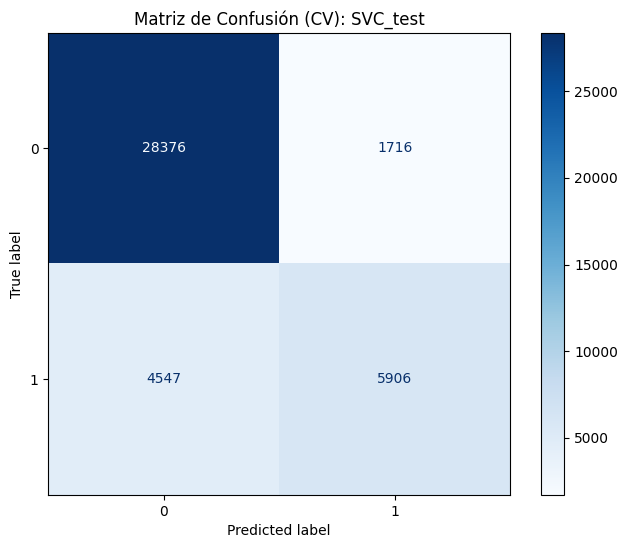

In [ ]:

def visualizar_matriz_confusion(modelo, X, y, nombre_modelo):
    """
    Genera y grafica la matriz de confusión utilizando predicciones 
    obtenidas mediante validación cruzada (StratifiedKFold).
    """
    # Configuramos una validación cruzada simple para la visualización
    cv_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    
    print(f"--- Generando matriz de confusión para: {nombre_modelo} ---")
    
    y_pred_cv = cross_val_predict(modelo, X, y, cv=cv_plot, n_jobs=-1)
    
    # Calculamos la matriz de confusión
    cm = confusion_matrix(y, y_pred_cv)
    
    # Graficamos
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    
    disp.plot(cmap='Blues', values_format='d', ax=plt.gca())
    plt.title(f'Matriz de Confusión: {nombre_modelo}')
    plt.grid(False)
    plt.show()

# --- BUCLE PARA MOSTRAR LAS MATRICES DE LOS MODELOS ENTRENADOS ---
for m in models_dic:
    if m.result is not None:
        estimator = m.result
        if not m.in_memory and hasattr(m, 'do_predict') and m.do_predict:
             try:
                 estimator = joblib.load(f'./saved_models/{m.name}.joblib')
             except:
                 print(f"No se pudo cargar el modelo {m.name} para graficar.")
                 continue
        
        visualizar_matriz_confusion(estimator, X_train, y_train, m.name)

## Predicción de los modelos

### Árbol de decisión

In [127]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)  # Filtrar los avisos de "futuro"
    
    #tree_predict = results_DT.predict(X_test)

### Naive Bayes

In [128]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)  # Filtrar los avisos de "futuro"
    
    #bayes_predict = results_NB.predict(X_test)

### Prediccion en conjunto

In [129]:
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=FutureWarning)  # Filtrar los avisos de "futuro"

    for model in models_dic:
        if (model.do_predict):
            if (not model.in_memory):
                model.result = joblib.load(f'./saved_models/{model.name}.joblib')
            model.prediction = model.result.predict(X_test)

## Predicciones a CSV

In [130]:
'''
predictions = [
    ("decision_tree",tree_predict),
    ("naive_bayes",bayes_predict)
    ]


def predictsToCsv():
    for (model_name,prediction) in predictions:
        output = pd.DataFrame({
            "id": df_test_raw["id"],
            "abandono": prediction
        })

        output.to_csv("./predictions/"+model_name+".csv",index=False)

'''

'\npredictions = [\n    ("decision_tree",tree_predict),\n    ("naive_bayes",bayes_predict)\n    ]\n\n\ndef predictsToCsv():\n    for (model_name,prediction) in predictions:\n        output = pd.DataFrame({\n            "id": df_test_raw["id"],\n            "abandono": prediction\n        })\n\n        output.to_csv("./predictions/"+model_name+".csv",index=False)\n\n'

### Predicciones en conjunto

In [131]:
def predictsToCsvBatch():
    for model in models_dic:
        if (model.do_predict):
            output = pd.DataFrame({
                "id": df_test_raw["id"],
                "abandono": model.prediction
            })

            output.to_csv("./predictions/"+model.name+".csv",index=False)

if (SUBIR_A_KAGGLE):   
    predictsToCsvBatch()

NOTAS P2
Bagging con Naive Bayes no suele ser buena idea. NB mejor con Boosting.


- Añadir alguna métrica (accuracy..)
- Matriz de confusión